# IEEE-CIS Fraud Detection: Production-Ready CPU Pipeline

This notebook implements a complete fraud detection pipeline for the IEEE-CIS Vesta dataset using only CPU-compatible Python packages:

- `pandas`
- `scikit-learn`
- `imbalanced-learn`
- `xgboost`
- `lightgbm`
- `catboost`
- `optuna`

The design goal is strict temporal discipline: features are built without leaking future information across the train/validation time boundary, target encoding is out-of-fold on training data only, and resampling is applied only to the training split.

## Pipeline Sections

1. Data loading and initial EDA  
2. Column reduction  
3. Preprocessing  
4. Feature engineering  
5. Imbalance handling  
6. Feature selection  
7. Hyperparameter tuning  
8. Ensemble model  
9. Validation and metrics  
10. UID postprocessing  
11. Output and artifact saving

## Imports, Paths, and Config

In [1]:
pip install optuna pandas scikit-learn xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Central configuration keeps the notebook adjustable without changing pipeline logic.
from __future__ import annotations

import gc
import hashlib
import json
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import ADASYN
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, KFold, TimeSeriesSplit
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "random_state": 42,
    "corr_threshold": 0.75,
    "train_fraction": 0.75,
    "target_encoding_folds": 5,
    "sampling_strategy": "none",  # changed to none due to version incompatibility
    "optuna_trials": 50,
    "optuna_timeout": None,
    "xgb_weight": 0.50,
    "lgbm_weight": 0.25,
    "cat_weight": 0.25,
    "drop_bottom_importance_pct": 0.10,
    "single_feature_first_month_days": 30,
    "single_feature_last_month_days": 30,
    "single_feature_n_estimators": 200,
    "early_stopping_rounds": 100,
    "xgb_base_params": {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "n_jobs": -1,
        "random_state": 42,
    },
    "lgbm_params": {
        "objective": "binary",
        "is_unbalance": True,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "n_estimators": 1200,
        "subsample": 0.85,
        "colsample_bytree": 0.80,
        "random_state": 42,
        "n_jobs": -1,
    },
    "cat_params": {
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "auto_class_weights": "Balanced",
        "depth": 8,
        "learning_rate": 0.05,
        "iterations": 1200,
        "verbose": 0,
        "random_seed": 42,
    },
}

SECONDS_IN_DAY = 86400
C_COLS = [f"C{i}" for i in range(1, 15)]
D_UID_COLS = ["D4", "D9", "D10", "D15"]
D_AGG_COLS = ["D9", "D11"]
M_COLS = [f"M{i}" for i in range(1, 10)]
TARGET_ENCODE_COLS = ["card1", "card2", "card3", "addr1", "P_emaildomain"]
FREQ_ENCODE_COLS = ["card1", "card2", "card3", "addr1", "P_emaildomain"]

print("Data directory:", DATA_DIR.resolve())
print("Artifacts directory:", ARTIFACT_DIR.resolve())

Data directory: /Users/adityadhayagude/Data_Mining_Project/data
Artifacts directory: /Users/adityadhayagude/Data_Mining_Project/artifacts


## Shared Utilities

In [3]:
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to lower-memory dtypes where possible."""
    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df


def normalize_identity_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize test-time id-* columns to the train-time id_* naming scheme."""
    rename_map = {col: col.replace("-", "_") for col in df.columns if col.startswith("id-")}
    if rename_map:
        df = df.rename(columns=rename_map)
    return df


def safe_mode(series: pd.Series):
    """Return the most common non-null value, or NaN if nothing is available."""
    non_null = series.dropna()
    if non_null.empty:
        return np.nan
    return non_null.mode(dropna=True).iloc[0]


def make_combo(df: pd.DataFrame, cols: list[str], sep: str = "_") -> pd.Series:
    """Create a stable string key from multiple columns for frequency and grouping features."""
    out = df[cols[0]].astype("string").fillna("missing")
    for col in cols[1:]:
        out = out + sep + df[col].astype("string").fillna("missing")
    return out


def factorize_column_pair(train_series: pd.Series, test_series: pd.Series) -> tuple[pd.Series, pd.Series]:
    """Factorize train and test together so categorical codes share the same integer mapping."""
    combined = pd.concat([train_series.astype("string"), test_series.astype("string")], axis=0)
    codes, uniques = pd.factorize(combined.fillna("missing"), sort=True)
    train_codes = pd.Series(codes[: len(train_series)], index=train_series.index).astype("int32")
    test_codes = pd.Series(codes[len(train_series):], index=test_series.index).astype("int32")
    train_codes = train_codes.where(train_series.notna(), -1)
    test_codes = test_codes.where(test_series.notna(), -1)
    return train_codes, test_codes


def get_month_index(transaction_dt: pd.Series) -> pd.Series:
    """Approximate month groups from elapsed seconds for grouped time validation."""
    return ((transaction_dt - transaction_dt.min()) // (30 * SECONDS_IN_DAY)).astype("int32")


def trailing_count(times: np.ndarray, window: int) -> np.ndarray:
    """Count how many prior events for a group fall inside a trailing time window."""
    left = np.searchsorted(times, times - window, side="left")
    return (np.arange(len(times)) - left).astype("float32")


def get_sampler(name: str, random_state: int):
    """Factory for selecting the requested resampling strategy."""
    if name == "smote_tomek":
        return SMOTETomek(random_state=random_state)
    if name == "smote_enn":
        return SMOTEENN(random_state=random_state)
    if name == "adasyn":
        return ADASYN(random_state=random_state)
    if name == "none":
        return None
    raise ValueError(f"Unsupported sampling strategy: {name}")

## 1. Data Loading and Initial EDA

In [4]:
def section_1_data_loading_and_initial_eda(data_dir: Path) -> dict[str, pd.DataFrame]:
    """Load raw IEEE-CIS transaction and identity tables, merge them, and print first-pass diagnostics."""
    train_transaction = pd.read_csv(data_dir / "train_transaction.csv")
    test_transaction = pd.read_csv(data_dir / "test_transaction.csv")
    train_identity = normalize_identity_columns(pd.read_csv(data_dir / "train_identity.csv"))
    test_identity = normalize_identity_columns(pd.read_csv(data_dir / "test_identity.csv"))

    train_df = train_transaction.merge(train_identity, on="TransactionID", how="left")
    test_df = test_transaction.merge(test_identity, on="TransactionID", how="left")
    train_df = reduce_mem_usage(train_df)
    test_df = reduce_mem_usage(test_df)

    print("Train shape:", train_df.shape)
    print("Test shape:", test_df.shape)
    print("\nTrain dtypes sample:")
    print(train_df.dtypes.head(25))

    train_missing = train_df.isna().mean().sort_values(ascending=False).mul(100)
    test_missing = test_df.isna().mean().sort_values(ascending=False).mul(100)
    missing_summary = pd.DataFrame({
        "train_missing_pct": train_missing,
        "test_missing_pct": test_missing,
    }).sort_values("train_missing_pct", ascending=False)
    print("\nTop 25 missing columns:")
    print(missing_summary.head(25))

    class_dist = train_df["isFraud"].value_counts(normalize=True).sort_index()
    fraud_rate = class_dist.get(1, 0.0)
    non_fraud_rate = class_dist.get(0, 0.0)
    imbalance_ratio = non_fraud_rate / max(fraud_rate, 1e-9)
    print("\nClass distribution:")
    print(train_df["isFraud"].value_counts())
    print(f"Fraud rate: {fraud_rate:.4%}")
    print(f"Imbalance ratio (non-fraud / fraud): {imbalance_ratio:.2f}")

    plt.figure(figsize=(12, 4))
    plt.hist(train_df["TransactionDT"], bins=100, alpha=0.6, label="train")
    plt.hist(test_df["TransactionDT"], bins=100, alpha=0.6, label="test")
    plt.title("TransactionDT distribution: train vs test")
    plt.xlabel("TransactionDT")
    plt.ylabel("Row count")
    plt.legend()
    plt.show()

    return {
        "train_df": train_df,
        "test_df": test_df,
        "missing_summary": missing_summary,
    }

## 2. Column Reduction

In [5]:
def section_2_column_reduction(train_df: pd.DataFrame, test_df: pd.DataFrame, corr_threshold: float) -> dict[str, object]:
    """Reduce redundant V and id columns by shared missingness pattern and correlation clustering."""
    candidate_cols = [c for c in train_df.columns if c.startswith("V") or c.startswith("id_")]
    combined = pd.concat([train_df[candidate_cols], test_df[candidate_cols]], axis=0, ignore_index=True)

    missing_groups: dict[str, list[str]] = defaultdict(list)
    for col in candidate_cols:
        mask_hash = hashlib.md5(combined[col].isna().to_numpy(dtype=np.uint8).tobytes()).hexdigest()
        missing_groups[mask_hash].append(col)

    kept = []
    dropped = []

    for cols in missing_groups.values():
        if len(cols) == 1:
            kept.extend(cols)
            continue

        corr_input = combined[cols].copy()
        numeric_cols = corr_input.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) < 2:
            kept.extend(cols)
            continue

        corr_input = corr_input[numeric_cols].fillna(corr_input[numeric_cols].median())
        corr_matrix = corr_input.corr().abs().fillna(0)
        for cluster in connected_components_from_corr(corr_matrix, corr_threshold):
            cluster_full = cluster
            if len(cluster_full) == 1:
                kept.extend(cluster_full)
                continue
            nunique = combined[cluster_full].nunique(dropna=True).sort_values(ascending=False)
            keep_col = nunique.index[0]
            kept.append(keep_col)
            dropped.extend([col for col in cluster_full if col != keep_col])

    kept = sorted(set(kept))
    dropped = sorted(set(dropped))
    base_cols = [c for c in train_df.columns if c not in candidate_cols]
    final_cols = base_cols + kept

    reduced_train = train_df[final_cols].copy()
    reduced_test = test_df[[col for col in final_cols if col in test_df.columns]].copy()

    print(f"Candidate V/id columns: {len(candidate_cols)}")
    print(f"Retained columns: {len(kept)}")
    print(f"Removed columns: {len(dropped)}")

    return {
        "train_df": reduced_train,
        "test_df": reduced_test,
        "kept_cols": kept,
        "dropped_cols": dropped,
    }

## 3. Preprocessing

In [6]:
def section_3_preprocessing(train_df: pd.DataFrame, test_df: pd.DataFrame, config: dict) -> dict[str, pd.DataFrame]:
    """Factorize categoricals, create amount split features, and define the time-based train/validation split."""
    train_df = train_df.copy()
    test_df = test_df.copy()

    categorical_cols = [c for c in train_df.columns if train_df[c].dtype == "object"]
    for col in categorical_cols:
        train_df[col], test_df[col] = factorize_column_pair(train_df[col], test_df[col])

    for df in [train_df, test_df]:
        amt_floor = np.floor(df["TransactionAmt"]).astype("int32")
        df["amt_dollars"] = amt_floor
        df["amt_cents"] = (((df["TransactionAmt"] - amt_floor) * 100).round()).fillna(0).astype("int32")
        df["day"] = (df["TransactionDT"] / SECONDS_IN_DAY).astype("float32")
        df["card1_addr1"] = make_combo(df, ["card1", "addr1"])

    train_df = train_df.sort_values("TransactionDT").reset_index(drop=True)
    split_idx = int(len(train_df) * config["train_fraction"])
    train_part = train_df.iloc[:split_idx].copy()
    valid_part = train_df.iloc[split_idx:].copy()

    print("Preprocessed train shape:", train_df.shape)
    print("Categorical columns factorized:", len(categorical_cols))
    print("Time split index:", split_idx)
    print("Train split shape:", train_part.shape)
    print("Valid split shape:", valid_part.shape)

    return {
        "train_df": train_df,
        "test_df": test_df,
        "train_part": train_part,
        "valid_part": valid_part,
        "categorical_cols": categorical_cols,
    }

## 4A-4D and 4E. Feature Engineering Helpers

In [7]:
def fit_frequency_maps(reference_df: pd.DataFrame) -> dict[str, pd.Series]:
    """Fit frequency encoders for single keys and the specified combined key."""
    reference = reference_df.copy()
    reference["card1_addr1"] = make_combo(reference, ["card1", "addr1"])
    maps = {}
    for col in FREQ_ENCODE_COLS:
        maps[f"{col}_FE"] = reference[col].value_counts(dropna=False)
    maps["card1_addr1_FE"] = reference["card1_addr1"].value_counts(dropna=False)
    return maps


def apply_frequency_maps(df: pd.DataFrame, freq_maps: dict[str, pd.Series]) -> pd.DataFrame:
    """Map fitted frequency counts into a target dataframe."""
    df = df.copy()
    df["card1_addr1"] = make_combo(df, ["card1", "addr1"])
    for feature_name, mapping in freq_maps.items():
        source_col = feature_name.replace("_FE", "")
        df[feature_name] = df[source_col].map(mapping).fillna(0).astype("float32")
    return df


def fit_aggregation_maps(reference_df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """Fit mean and std lookups for the required entity groupings."""
    reference = reference_df.copy()
    reference["card1_addr1"] = make_combo(reference, ["card1", "addr1"])
    reference["card1_addr1_P_emaildomain"] = make_combo(reference, ["card1", "addr1", "P_emaildomain"])
    group_defs = {
        "card1": ["card1"],
        "card1_addr1": ["card1_addr1"],
        "card1_addr1_P_emaildomain": ["card1_addr1_P_emaildomain"],
    }
    value_cols = ["TransactionAmt", "D9", "D11"]
    maps = {}
    for name, keys in group_defs.items():
        grouped = reference.groupby(keys, dropna=False)[value_cols].agg(["mean", "std"])
        grouped.columns = [f"{name}_{col}_{stat}" for col, stat in grouped.columns]
        maps[name] = grouped.reset_index()
    return maps


def apply_aggregation_maps(df: pd.DataFrame, agg_maps: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Attach aggregation statistics to target rows via left joins on entity keys."""
    df = df.copy()
    df["card1_addr1"] = make_combo(df, ["card1", "addr1"])
    df["card1_addr1_P_emaildomain"] = make_combo(df, ["card1", "addr1", "P_emaildomain"])
    for name, table in agg_maps.items():
        key_cols = [col for col in table.columns if not col.endswith("_mean") and not col.endswith("_std")]
        key_cols = [col for col in key_cols if col in df.columns]
        df = df.merge(table, on=key_cols, how="left")
    return df


def apply_target_encoding_oof(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cols: list[str],
    target_col: str,
    n_splits: int,
    random_state: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Fit leakage-safe 5-fold out-of-fold target encodings on training data only."""
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()
    global_mean = train_df[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=False)

    for col in cols:
        oof = pd.Series(np.nan, index=train_df.index, dtype="float32")
        for fit_idx, hold_idx in kf.split(train_df):
            fit_frame = train_df.iloc[fit_idx]
            hold_frame = train_df.iloc[hold_idx]
            mapping = fit_frame.groupby(col, dropna=False)[target_col].mean()
            oof.loc[hold_frame.index] = hold_frame[col].map(mapping).fillna(global_mean).astype("float32")
        full_mapping = train_df.groupby(col, dropna=False)[target_col].mean()
        train_df[f"{col}_TE"] = oof.fillna(global_mean).astype("float32")
        valid_df[f"{col}_TE"] = valid_df[col].map(full_mapping).fillna(global_mean).astype("float32")
        test_df[f"{col}_TE"] = test_df[col].map(full_mapping).fillna(global_mean).astype("float32")

    return train_df, valid_df, test_df


def build_uid(df: pd.DataFrame) -> pd.Series:
    """Create the requested UID string without exposing the raw UID directly to the model."""
    uid_day = np.floor(df["day"] - df["D1"].fillna(-999)).astype("int32").astype("string")
    return make_combo(pd.DataFrame({"card1_addr1": df["card1_addr1"], "uid_day": uid_day}), ["card1_addr1", "uid_day"])

## 4D and 4E. UID, Deviation, Velocity, and Drift Features

In [8]:
def fit_uid_reference_maps(reference_df: pd.DataFrame) -> dict[str, object]:
    """Fit UID-level lookup tables from training history only for aggregation, deviation, and identity-consistency features."""
    ref = reference_df.copy()
    ref["uid"] = build_uid(ref)
    ref["uid2"] = make_combo(
        pd.DataFrame({
            "card1": ref["card1"],
            "card2": ref["card2"],
            "addr1": ref["addr1"],
            "uid_day": np.floor(ref["day"] - ref["D1"].fillna(-999)).astype("int32"),
        }),
        ["card1", "card2", "addr1", "uid_day"],
    )
    
    # Hour of day calculations
    ref["hour_of_day"] = ((ref["TransactionDT"] % SECONDS_IN_DAY) // 3600).astype("int16")
    
    # Convert 'T'/'F' strings to 1/0
    for col in M_COLS:
        if col in ref.columns:
            ref[col] = pd.to_numeric(ref[col].replace({"T": 1, "F": 0}), errors="coerce")
            
    # Calculate the row-level match score
    ref["M_mean_row"] = ref[M_COLS].astype("float32").mean(axis=1)

    uid_stats = ref.groupby("uid", dropna=False).agg({
        "TransactionAmt": ["mean", "std", "max"],
        "D4": "mean",
        "D9": "mean",
        "D10": "mean",
        "D15": "mean",
    })
    uid_stats.columns = [
        "TransactionAmt_uid_mean", "TransactionAmt_uid_std", "uid_amt_max",
        "D4_uid_mean", "D9_uid_mean", "D10_uid_mean", "D15_uid_mean"
    ]

    c_means = ref.groupby("uid", dropna=False)[[c for c in C_COLS if c in ref.columns]].mean()
    c_means.columns = [f"{c}_uid_mean" for c in c_means.columns]

    m_means = ref.groupby("uid", dropna=False)[[m for m in M_COLS if m in ref.columns]].mean()
    m_means.columns = [f"{m}_uid_mean" for m in m_means.columns]

    # --- THE LIGHTGBM FIX: Force PyArrow to standard int32 ---
    uid_freq = ref["uid"].value_counts(dropna=False).astype("int32").rename("uid_freq").to_frame()

    # Calculate both mean and MEDIAN time gaps between purchases
    gap_rows = []
    for uid_value, group in ref.sort_values("TransactionDT").groupby("uid", dropna=False):
        diffs = group["TransactionDT"].diff()
        gap_rows.append((uid_value, diffs.mean(), diffs.median()))
    uid_gaps = pd.DataFrame(gap_rows, columns=["uid", "uid_dt_diff_mean", "uid_median_gap"]).set_index("uid")

    hour_stats = ref.groupby("uid", dropna=False)["hour_of_day"].agg(
        uid_hour_q1=lambda x: x.quantile(0.25),
        uid_hour_q3=lambda x: x.quantile(0.75)
    )

    m_consistency = ref.groupby("uid", dropna=False)["M_mean_row"].mean().rename("M_consistency_score").to_frame()

    # Stitch ALL tables together into one master 'uid_lookup' table
    uid_lookup = pd.concat([uid_stats, c_means, m_means, uid_freq, uid_gaps, hour_stats, m_consistency], axis=1).reset_index()

    # Calculate the historical sets of devices and emails for each user
    device_sets = ref.groupby("uid")["DeviceInfo"].apply(lambda x: set(x.dropna())).to_dict() if "DeviceInfo" in ref.columns else {}
    email_sets = ref.groupby("uid")["P_emaildomain"].apply(lambda x: set(x.dropna())).to_dict() if "P_emaildomain" in ref.columns else {}
    
    if "DeviceInfo" in ref.columns and "id_30" in ref.columns:
        ref["device_combo"] = make_combo(ref, ["DeviceInfo", "id_30"])
        os_combo_sets = ref.groupby("uid")["device_combo"].apply(lambda x: set(x.dropna())).to_dict()
    else:
        os_combo_sets = {}

    return {
        "uid_lookup": uid_lookup,
        "device_sets": device_sets,
        "email_sets": email_sets,
        "os_combo_sets": os_combo_sets
    }
def apply_uid_reference_features(df: pd.DataFrame, uid_maps: dict[str, object]) -> pd.DataFrame:
    """Map training-only UID statistics into any target dataframe for deviation and identity-drift features."""
    df = df.copy()
    df["uid"] = build_uid(df)
    df["uid2"] = make_combo(
        pd.DataFrame({
            "card1": df["card1"],
            "card2": df["card2"],
            "addr1": df["addr1"],
            "uid_day": np.floor(df["day"] - df["D1"].fillna(-999)).astype("int32"),
        }),
        ["card1", "card2", "addr1", "uid_day"],
    )
    # Convert 'T'/'F' strings to 1/0 before doing the row mean
    for col in M_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace({"T": 1, "F": 0}), errors="coerce")
            
    df["M_mean_row"] = df[M_COLS].astype("float32").mean(axis=1)
    df = df.merge(uid_maps["uid_lookup"], on="uid", how="left")

    df["amt_zscore"] = (df["TransactionAmt"] - df["TransactionAmt_uid_mean"]) / (df["TransactionAmt_uid_std"] + 1e-9)
    df["amt_pct_of_historical_max"] = df["TransactionAmt"] / (df["uid_amt_max"] + 1e-9)

    for col in [c for c in C_COLS if c in df.columns]:
        df[f"{col}_delta"] = df[col] - df[f"{col}_uid_mean"]
    for col in [d for d in D_UID_COLS if d in df.columns]:
        df[f"{col}_delta"] = df[col] - df[f"{col}_uid_mean"]

    df["hour_of_day"] = ((df["TransactionDT"] % SECONDS_IN_DAY) // 3600).astype("int16")
    df["is_unusual_hour"] = (
        (df["hour_of_day"] < df["uid_hour_q1"]) | (df["hour_of_day"] > df["uid_hour_q3"])
    ).fillna(False).astype("int8")

    df["is_new_device"] = 0
    df["is_new_email"] = 0
    df["device_os_match"] = 1
    device_combo = make_combo(df, ["DeviceInfo", "id_30"])

    device_sets = uid_maps["device_sets"]
    email_sets = uid_maps["email_sets"]
    os_combo_sets = uid_maps["os_combo_sets"]
    for idx, uid_value in enumerate(df["uid"].tolist()):
        device = df.iloc[idx]["DeviceInfo"]
        email = df.iloc[idx]["P_emaildomain"]
        combo = device_combo.iloc[idx]
        df.iloc[idx, df.columns.get_loc("is_new_device")] = int(device not in device_sets.get(uid_value, set()))
        df.iloc[idx, df.columns.get_loc("is_new_email")] = int(email not in email_sets.get(uid_value, set()))
        df.iloc[idx, df.columns.get_loc("device_os_match")] = int(combo in os_combo_sets.get(uid_value, set()))

    df["M_delta"] = df["M_mean_row"] - df["M_consistency_score"]
    return df


def add_sequential_uid_time_features(train_df: pd.DataFrame, valid_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Compute prior-only gap and velocity features by processing train, validation, and test in chronological order."""
    frames = []
    for name, frame in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
        copy_frame = frame.copy()
        copy_frame["_dataset_name"] = name
        copy_frame["_row_id"] = np.arange(len(copy_frame))
        frames.append(copy_frame)

    combined = pd.concat(frames, axis=0, ignore_index=True)
    combined = combined.sort_values("TransactionDT").reset_index(drop=True)
    combined["time_since_last_txn"] = np.nan
    combined["txn_velocity_1h"] = 0.0
    combined["txn_velocity_24h"] = 0.0
    combined["is_burst"] = 0

    for uid_value, idx in combined.groupby("uid", dropna=False).groups.items():
        idx = np.asarray(idx)
        group = combined.loc[idx]
        times = group["TransactionDT"].to_numpy(dtype="int64")
        combined.loc[idx, "time_since_last_txn"] = group["TransactionDT"].diff().to_numpy()
        combined.loc[idx, "txn_velocity_1h"] = trailing_count(times, 3600)
        combined.loc[idx, "txn_velocity_24h"] = trailing_count(times, 24 * 3600)
        combined.loc[idx, "is_burst"] = (combined.loc[idx, "txn_velocity_1h"] > 3).astype("int8")

    combined["time_gap_vs_normal"] = combined["time_since_last_txn"] / (combined["uid_median_gap"] + 1e-9)

    out = {}
    for name in ["train", "valid", "test"]:
        subset = combined.loc[combined["_dataset_name"] == name].sort_values("_row_id").drop(columns=["_dataset_name", "_row_id"])
        out[name] = subset.reset_index(drop=True)
    return out["train"], out["valid"], out["test"]

## 4. Feature Engineering Orchestration

In [9]:
def section_4_feature_engineering(
    train_part: pd.DataFrame,
    valid_part: pd.DataFrame,
    test_df: pd.DataFrame,
    config: dict,
) -> dict[str, pd.DataFrame]:
    """Build the full engineered feature space while preserving the time boundary between train and validation."""
    train_part = train_part.copy()
    valid_part = valid_part.copy()
    test_df = test_df.copy()

    freq_maps = fit_frequency_maps(train_part)
    agg_maps = fit_aggregation_maps(train_part)
    uid_maps = fit_uid_reference_maps(train_part)

    train_feat = apply_frequency_maps(train_part, freq_maps)
    valid_feat = apply_frequency_maps(valid_part, freq_maps)
    test_feat = apply_frequency_maps(test_df, freq_maps)

    train_feat = apply_aggregation_maps(train_feat, agg_maps)
    valid_feat = apply_aggregation_maps(valid_feat, agg_maps)
    test_feat = apply_aggregation_maps(test_feat, agg_maps)

    train_feat, valid_feat, test_feat = apply_target_encoding_oof(
        train_feat,
        valid_feat,
        test_feat,
        TARGET_ENCODE_COLS,
        target_col="isFraud",
        n_splits=config["target_encoding_folds"],
        random_state=config["random_state"],
    )

    train_feat = apply_uid_reference_features(train_feat, uid_maps)
    valid_feat = apply_uid_reference_features(valid_feat, uid_maps)
    test_feat = apply_uid_reference_features(test_feat, uid_maps)
    train_feat, valid_feat, test_feat = add_sequential_uid_time_features(train_feat, valid_feat, test_feat)

    # ---------------------------------------------------------
    # NEW CUSTOM FEATURES: Paste this block right here!
    # ---------------------------------------------------------
    for df in [train_feat, valid_feat, test_feat]:
        # 1. Cents Matters: Extract the decimal portion of the amount
        # We round to 2 decimal places to prevent weird float math like 0.9899999
        df["TransactionAmt_cents"] = np.round(df["TransactionAmt"] % 1, 2)
        
        # 2. Email Matching: 1 if emails match, 0 otherwise
        valid_emails = df["P_emaildomain"].notna() & df["R_emaildomain"].notna()
        df["email_match"] = (valid_emails & (df["P_emaildomain"] == df["R_emaildomain"])).astype("int8")
        
        # 3. Spend Velocity Ratio: Est. 24h spend divided by historical average transaction
        if "txn_velocity_24h" in df.columns and "TransactionAmt_uid_mean" in df.columns:
            approx_24h_spend = df["txn_velocity_24h"] * df["TransactionAmt"]
            df["spend_velocity_ratio"] = approx_24h_spend / (df["TransactionAmt_uid_mean"] + 1e-9)

    exclude_features = {"isFraud", "uid", "uid2", "card1_addr1", "card1_addr1_P_emaildomain"}
    feature_cols = [
        col for col in train_feat.columns
        if col not in exclude_features and pd.api.types.is_numeric_dtype(train_feat[col])
    ]

    print("Engineered train shape:", train_feat.shape)
    print("Engineered valid shape:", valid_feat.shape)
    print("Engineered test shape:", test_feat.shape)
    print("Numeric candidate features:", len(feature_cols))

    return {
        "train_feat": train_feat,
        "valid_feat": valid_feat,
        "test_feat": test_feat,
        "feature_cols": feature_cols,
        "uid_maps": uid_maps,
        "freq_maps": freq_maps,
        "agg_maps": agg_maps,
    }

## 5. Imbalance Handling

In [10]:
def section_5_handle_imbalance(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    sampling_strategy: str,
    random_state: int,
) -> dict[str, object]:
    """Apply the configured training-only resampling method and report class balance before and after."""
    print("Class distribution before resampling:")
    print(y_train.value_counts())

    sampler = get_sampler(sampling_strategy, random_state)
    if sampler is None:
        X_resampled = X_train.copy()
        y_resampled = y_train.copy()
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    y_resampled = pd.Series(y_resampled, name=y_train.name)
    print("\nClass distribution after resampling:")
    print(y_resampled.value_counts())

    return {
        "X_train_resampled": X_resampled,
        "y_train_resampled": y_resampled,
        "sampler": sampler,
    }

## 6. Feature Selection

In [11]:
def build_single_feature_month_split(train_feat: pd.DataFrame, y_train: pd.Series, config: dict) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Define an early-vs-late month split inside the training window for single-feature AUC testing."""
    first_cut = train_feat["TransactionDT"].min() + config["single_feature_first_month_days"] * SECONDS_IN_DAY
    last_cut = train_feat["TransactionDT"].max() - config["single_feature_last_month_days"] * SECONDS_IN_DAY

    early_mask = train_feat["TransactionDT"] <= first_cut
    late_mask = train_feat["TransactionDT"] >= last_cut
    if early_mask.sum() == 0 or late_mask.sum() == 0:
        midpoint = int(len(train_feat) * 0.5)
        early_mask = np.zeros(len(train_feat), dtype=bool)
        early_mask[:midpoint] = True
        late_mask = ~early_mask

    return (
        train_feat.loc[early_mask].reset_index(drop=True),
        train_feat.loc[late_mask].reset_index(drop=True),
        y_train.loc[early_mask].reset_index(drop=True),
        y_train.loc[late_mask].reset_index(drop=True),
    )


def section_6_feature_selection(
    train_feat: pd.DataFrame,
    valid_feat: pd.DataFrame,
    feature_cols: list[str],
    config: dict,
) -> dict[str, object]:
    """Filter weak features with single-feature AUC tests, then prune low-importance features from a full XGBoost model."""
    y_train = train_feat["isFraud"].astype("int8").reset_index(drop=True)
    y_valid = valid_feat["isFraud"].astype("int8").reset_index(drop=True)
    early_X, late_X, early_y, late_y = build_single_feature_month_split(train_feat, y_train, config)

    removed = []
    surviving = []
    feature_auc_rows = []

    for feature in feature_cols:
        X_early = early_X[[feature]].fillna(-999)
        X_late = late_X[[feature]].fillna(-999)
        model = XGBClassifier(
            **CONFIG["xgb_base_params"],
            n_estimators=config["single_feature_n_estimators"],
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
        )
        try:
            model.fit(X_early, early_y)
            early_pred = model.predict_proba(X_early)[:, 1]
            late_pred = model.predict_proba(X_late)[:, 1]
            train_auc = roc_auc_score(early_y, early_pred)
            val_auc = roc_auc_score(late_y, late_pred)
        except Exception:
            train_auc = 0.5
            val_auc = 0.5

        feature_auc_rows.append((feature, train_auc, val_auc))
        if train_auc <= 0.5 and val_auc <= 0.5:
            removed.append(feature)
        else:
            surviving.append(feature)

    print("Removed by single-feature AUC filter:")
    print(removed[:100], "..." if len(removed) > 100 else "")

    X_train = train_feat[surviving].fillna(-999).reset_index(drop=True)
    X_valid = valid_feat[surviving].fillna(-999).reset_index(drop=True)
    y_train = train_feat["isFraud"].astype("int8").reset_index(drop=True)
    y_valid = valid_feat["isFraud"].astype("int8").reset_index(drop=True)

    imbalance = y_train.value_counts()
    scale_pos_weight = imbalance.get(0, 1) / max(imbalance.get(1, 1), 1)
    resampled = section_5_handle_imbalance(X_train, y_train, config["sampling_strategy"], config["random_state"])

    full_model = XGBClassifier(
        **CONFIG["xgb_base_params"],
        n_estimators=1200,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        scale_pos_weight=scale_pos_weight,
    )
    full_model.fit(
        resampled["X_train_resampled"],
        resampled["y_train_resampled"],
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )
    valid_pred = full_model.predict_proba(X_valid)[:, 1]
    valid_auc = roc_auc_score(y_valid, valid_pred)
    print(f"Validation AUC with surviving features: {valid_auc:.6f}")

    importance = pd.Series(full_model.feature_importances_, index=surviving).sort_values(ascending=False)
    bottom_n = max(1, int(len(importance) * config["drop_bottom_importance_pct"]))
    bottom_features = importance.tail(bottom_n).index.tolist()
    final_features = [f for f in surviving if f not in bottom_features]

    return {
        "feature_auc_table": pd.DataFrame(feature_auc_rows, columns=["feature", "train_auc", "val_auc"]),
        "removed_features": removed,
        "surviving_features": surviving,
        "final_features": final_features,
        "importance": importance,
        "baseline_valid_auc": valid_auc,
    }

## 7. Hyperparameter Tuning with Optuna

In [12]:
def section_7_hyperparameter_tuning(
    train_feat: pd.DataFrame,
    feature_cols: list[str],
    config: dict,
) -> dict[str, object]:
    """Tune XGBoost hyperparameters with Optuna using TimeSeriesSplit and training-fold-only resampling."""
    X = train_feat[feature_cols].fillna(-999).reset_index(drop=True)
    y = train_feat["isFraud"].astype("int8").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=3)

    def objective(trial: optuna.Trial) -> float:
        params = {
            **CONFIG["xgb_base_params"],
            "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        }

        fold_scores = []
        for fit_idx, hold_idx in tscv.split(X):
            X_fit = X.iloc[fit_idx]
            y_fit = y.iloc[fit_idx]
            X_hold = X.iloc[hold_idx]
            y_hold = y.iloc[hold_idx]

            class_counts = y_fit.value_counts()
            params["scale_pos_weight"] = class_counts.get(0, 1) / max(class_counts.get(1, 1), 1)
            sampled = section_5_handle_imbalance(X_fit, y_fit, config["sampling_strategy"], config["random_state"])

            model = XGBClassifier(**params)
            model.fit(
                sampled["X_train_resampled"],
                sampled["y_train_resampled"],
                eval_set=[(X_hold, y_hold)],
                verbose=False,
            )
            hold_pred = model.predict_proba(X_hold)[:, 1]
            fold_scores.append(roc_auc_score(y_hold, hold_pred))
        return float(np.mean(fold_scores))

    study = optuna.create_study(direction="maximize", study_name="ieee_cis_xgb_cpu")
    study.optimize(objective, n_trials=config["optuna_trials"], timeout=config["optuna_timeout"])

    print("Best Optuna AUC:", study.best_value)
    print("Best Optuna params:")
    print(study.best_params)

    return {
        "study": study,
        "best_params": study.best_params,
        "best_score": study.best_value,
    }

## 8. Ensemble Model

In [13]:
def section_8_train_ensemble(
    train_feat: pd.DataFrame,
    valid_feat: pd.DataFrame,
    feature_cols: list[str],
    best_xgb_params: dict,
    config: dict,
) -> dict[str, object]:
    """Train XGBoost, LightGBM, and CatBoost on the resampled training set and blend their predictions."""
    X_train = train_feat[feature_cols].fillna(-999).reset_index(drop=True)
    y_train = train_feat["isFraud"].astype("int8").reset_index(drop=True)
    X_valid = valid_feat[feature_cols].fillna(-999).reset_index(drop=True)
    y_valid = valid_feat["isFraud"].astype("int8").reset_index(drop=True)

    class_counts = y_train.value_counts()
    scale_pos_weight = class_counts.get(0, 1) / max(class_counts.get(1, 1), 1)
    sampled = section_5_handle_imbalance(X_train, y_train, config["sampling_strategy"], config["random_state"])

    xgb_params = {**CONFIG["xgb_base_params"], **best_xgb_params, "scale_pos_weight": scale_pos_weight}
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(
        sampled["X_train_resampled"],
        sampled["y_train_resampled"],
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )

    lgbm_model = LGBMClassifier(**CONFIG["lgbm_params"])
    lgbm_model.fit(sampled["X_train_resampled"], sampled["y_train_resampled"])

    cat_model = CatBoostClassifier(**CONFIG["cat_params"])
    cat_model.fit(sampled["X_train_resampled"], sampled["y_train_resampled"])

    xgb_pred = xgb_model.predict_proba(X_valid)[:, 1]
    lgbm_pred = lgbm_model.predict_proba(X_valid)[:, 1]
    cat_pred = cat_model.predict_proba(X_valid)[:, 1]

    blended_pred = (
        config["xgb_weight"] * xgb_pred +
        config["lgbm_weight"] * lgbm_pred +
        config["cat_weight"] * cat_pred
    )

    return {
        "xgb_model": xgb_model,
        "lgbm_model": lgbm_model,
        "cat_model": cat_model,
        "xgb_pred": xgb_pred,
        "lgbm_pred": lgbm_pred,
        "cat_pred": cat_pred,
        "blended_pred": blended_pred,
        "y_valid": y_valid,
        "X_valid": X_valid,
    }

## 9. Validation and Metrics

In [14]:
def section_9_validation_and_metrics(
    train_feat: pd.DataFrame,
    valid_feat: pd.DataFrame,
    blended_pred: np.ndarray,
    feature_cols: list[str],
    best_xgb_params: dict,
    config: dict,
) -> dict[str, object]:
    """Compute validation metrics, plot ROC/PR curves, and report GroupKFold month-based cross-validation AUC."""
    y_valid = valid_feat["isFraud"].astype("int8").reset_index(drop=True)

    auc_roc = roc_auc_score(y_valid, blended_pred)
    pr_auc = average_precision_score(y_valid, blended_pred)
    hard_pred = (blended_pred >= 0.5).astype("int8")
    f1 = f1_score(y_valid, hard_pred)
    precision = precision_score(y_valid, hard_pred, zero_division=0)
    recall = recall_score(y_valid, hard_pred, zero_division=0)
    cm = confusion_matrix(y_valid, hard_pred)

    print(f"AUC-ROC: {auc_roc:.6f}")
    print(f"PR-AUC: {pr_auc:.6f}")
    print(f"F1@0.5: {f1:.6f}")
    print(f"Precision@0.5: {precision:.6f}")
    print(f"Recall@0.5: {recall:.6f}")
    print("Confusion matrix:")
    print(cm)

    fpr, tpr, _ = roc_curve(y_valid, blended_pred)
    pr_precision, pr_recall, _ = precision_recall_curve(y_valid, blended_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(fpr, tpr, label=f"ROC AUC = {auc_roc:.4f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title("ROC Curve")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()

    axes[1].plot(pr_recall, pr_precision, label=f"PR AUC = {pr_auc:.4f}")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    full_train = train_feat.copy().reset_index(drop=True)
    X_full = full_train[feature_cols].fillna(-999)
    y_full = full_train["isFraud"].astype("int8")
    month_groups = get_month_index(full_train["TransactionDT"])
    gkf = GroupKFold(n_splits=min(3, month_groups.nunique()))
    cv_scores = []

    for fit_idx, hold_idx in gkf.split(X_full, y_full, groups=month_groups):
        X_fit = X_full.iloc[fit_idx]
        y_fit = y_full.iloc[fit_idx]
        X_hold = X_full.iloc[hold_idx]
        y_hold = y_full.iloc[hold_idx]

        class_counts = y_fit.value_counts()
        scale_pos_weight = class_counts.get(0, 1) / max(class_counts.get(1, 1), 1)
        sampled = section_5_handle_imbalance(X_fit, y_fit, config["sampling_strategy"], config["random_state"])
        model = XGBClassifier(**CONFIG["xgb_base_params"], **best_xgb_params, scale_pos_weight=scale_pos_weight)
        model.fit(sampled["X_train_resampled"], sampled["y_train_resampled"], eval_set=[(X_hold, y_hold)], verbose=False)
        hold_pred = model.predict_proba(X_hold)[:, 1]
        cv_scores.append(roc_auc_score(y_hold, hold_pred))

    print("GroupKFold month-based CV AUCs:", cv_scores)
    print("GroupKFold month-based CV mean AUC:", float(np.mean(cv_scores)))

    return {
        "auc_roc": auc_roc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": cm,
        "groupkfold_auc_scores": cv_scores,
    }

## 10. UID Postprocessing

In [15]:
def section_10_uid_postprocessing(valid_feat: pd.DataFrame, blended_pred: np.ndarray) -> dict[str, object]:
    """Average predictions within refined UID2 groups and compare validation AUC before and after smoothing."""
    valid_df = valid_feat.copy().reset_index(drop=True)
    raw_auc = roc_auc_score(valid_df["isFraud"], blended_pred)
    valid_df["pred_raw"] = blended_pred
    valid_df["pred_uid2_mean"] = valid_df.groupby("uid2", dropna=False)["pred_raw"].transform("mean")
    post_auc = roc_auc_score(valid_df["isFraud"], valid_df["pred_uid2_mean"])

    print(f"Validation AUC before UID2 averaging: {raw_auc:.6f}")
    print(f"Validation AUC after UID2 averaging: {post_auc:.6f}")

    return {
        "valid_pred_raw": blended_pred,
        "valid_pred_post": valid_df["pred_uid2_mean"].to_numpy(),
        "val_auc_pre": raw_auc,
        "val_auc_post": post_auc,
    }

## 11. Final Output and Artifact Saving

In [16]:
def section_11_output(
    full_train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list[str],
    best_xgb_params: dict,
    config: dict,
    summary_metrics: dict[str, float],
) -> dict[str, object]:
    """Refit the final ensemble on full training data, save submission and XGBoost artifacts, and print a summary table."""
    preprocessed = section_3_preprocessing(full_train_df, test_df, config)
    full_train_sorted = preprocessed["train_df"]
    test_sorted = preprocessed["test_df"]

    engineered = section_4_feature_engineering(full_train_sorted, full_train_sorted.iloc[0:0].copy(), test_sorted, config)
    full_train_feat = engineered["train_feat"]
    test_feat = engineered["test_feat"]

    X_full = full_train_feat[feature_cols].fillna(-999).reset_index(drop=True)
    y_full = full_train_feat["isFraud"].astype("int8").reset_index(drop=True)
    X_test = test_feat[feature_cols].fillna(-999).reset_index(drop=True)

    class_counts = y_full.value_counts()
    scale_pos_weight = class_counts.get(0, 1) / max(class_counts.get(1, 1), 1)
    sampled = section_5_handle_imbalance(X_full, y_full, config["sampling_strategy"], config["random_state"])

    xgb_model = XGBClassifier(**CONFIG["xgb_base_params"], **best_xgb_params, scale_pos_weight=scale_pos_weight)
    xgb_model.fit(sampled["X_train_resampled"], sampled["y_train_resampled"], verbose=False)

    lgbm_model = LGBMClassifier(**CONFIG["lgbm_params"])
    lgbm_model.fit(sampled["X_train_resampled"], sampled["y_train_resampled"])

    cat_model = CatBoostClassifier(**CONFIG["cat_params"])
    cat_model.fit(sampled["X_train_resampled"], sampled["y_train_resampled"])

    xgb_pred = xgb_model.predict_proba(X_test)[:, 1]
    lgbm_pred = lgbm_model.predict_proba(X_test)[:, 1]
    cat_pred = cat_model.predict_proba(X_test)[:, 1]
    blended_pred = (
        config["xgb_weight"] * xgb_pred +
        config["lgbm_weight"] * lgbm_pred +
        config["cat_weight"] * cat_pred
    )

    submission = pd.DataFrame({
        "TransactionID": test_feat["TransactionID"].to_numpy(),
        "isFraud": blended_pred,
    })
    submission["isFraud"] = submission.groupby(test_feat["uid2"], dropna=False)["isFraud"].transform("mean")
    submission_path = ARTIFACT_DIR / "submission.csv"
    submission.to_csv(submission_path, index=False)

    model_path = ARTIFACT_DIR / "fraud_xgb_model.json"
    xgb_model.save_model(model_path)

    summary_table = pd.DataFrame({
        "features_used": [len(feature_cols)],
        "resampling_method": [config["sampling_strategy"]],
        "val_auc_pre_postprocess": [summary_metrics["val_auc_pre"]],
        "val_auc_post_postprocess": [summary_metrics["val_auc_post"]],
        "pr_auc": [summary_metrics["pr_auc"]],
    })
    print(summary_table)

    return {
        "submission_path": submission_path,
        "model_path": model_path,
        "summary_table": summary_table,
    }

In [17]:
def connected_components_from_corr(corr_matrix: pd.DataFrame, threshold: float) -> list[list[str]]:
    """
    Find groups (connected components) of highly correlated columns.
    If column A is correlated with B, and B with C, [A, B, C] form a cluster.
    """
    visited = set()
    components = []
    
    # Loop through every column in the correlation matrix
    for col in corr_matrix.columns:
        if col not in visited:
            # Start a new cluster
            component = []
            queue = [col]
            
            # Find all connected columns using Breadth-First Search (BFS)
            while queue:
                current = queue.pop(0)
                if current not in visited:
                    visited.add(current)
                    component.append(current)
                    
                    # Find all other columns highly correlated with the 'current' column
                    highly_corr = corr_matrix.index[
                        (corr_matrix[current] > threshold) & (corr_matrix.index != current)
                    ].tolist()
                    
                    for neighbor in highly_corr:
                        if neighbor not in visited and neighbor not in queue:
                            queue.append(neighbor)
                            
            components.append(component)
            
    return components

## Pipeline Orchestration

Train shape: (590540, 434)
Test shape: (506691, 433)

Train dtypes sample:
TransactionID       int32
isFraud              int8
TransactionDT       int32
TransactionAmt    float32
ProductCD             str
card1               int16
card2             float32
card3             float32
card4                 str
card5             float32
card6                 str
addr1             float32
addr2             float32
dist1             float32
dist2             float32
P_emaildomain         str
R_emaildomain         str
C1                float32
C2                float32
C3                float32
C4                float32
C5                float32
C6                float32
C7                float32
C8                float32
dtype: object

Top 25 missing columns:
       train_missing_pct  test_missing_pct
id_24          99.196159         99.064519
id_25          99.130965         99.005508
id_08          99.127070         99.001561
id_07          99.127070         99.001561
id_21          99.126

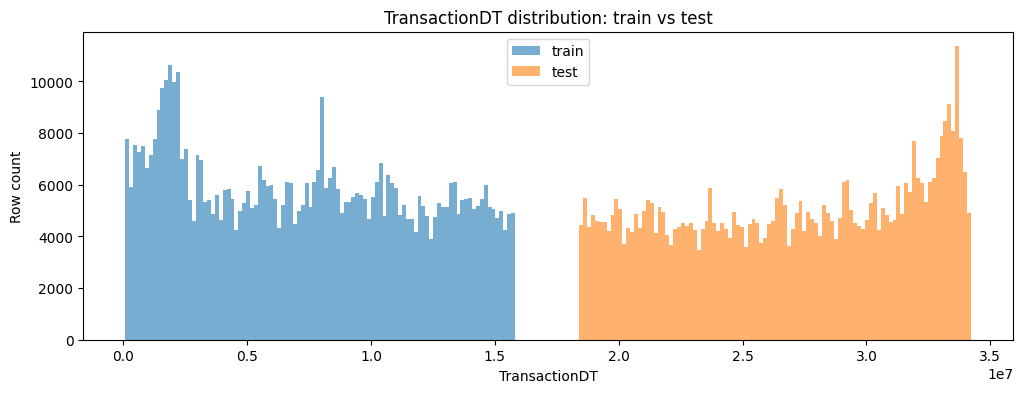

Candidate V/id columns: 377
Retained columns: 164
Removed columns: 213
Preprocessed train shape: (590540, 225)
Categorical columns factorized: 0
Time split index: 442905
Train split shape: (442905, 225)
Valid split shape: (147635, 225)
Engineered train shape: (442905, 328)
Engineered valid shape: (147635, 328)
Engineered test shape: (506691, 328)
Numeric candidate features: 301
Removed by single-feature AUC filter:
['M4', 'V107', 'V305', 'M4_uid_mean', 'device_os_match'] 
Class distribution before resampling:
isFraud
0    427342
1     15563
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    427342
1     15563
Name: count, dtype: int64


[I 2026-04-04 12:34:59,048] A new study created in memory with name: ieee_cis_xgb_cpu


Validation AUC with surviving features: 0.901874
Class distribution before resampling:
isFraud
0    108006
1      2721
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    108006
1      2721
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    214551
1      6902
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    214551
1      6902
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    320964
1     11215
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    320964
1     11215
Name: count, dtype: int64


[I 2026-04-04 12:36:11,597] Trial 0 finished with value: 0.9213393812706349 and parameters: {'n_estimators': 873, 'max_depth': 8, 'learning_rate': 0.006797354636737983, 'subsample': 0.7777118968781441, 'colsample_bytree': 0.523312952315552, 'min_child_weight': 1, 'reg_alpha': 0.6498318837388344, 'reg_lambda': 0.15087462382349118}. Best is trial 0 with value: 0.9213393812706349.


Class distribution before resampling:
isFraud
0    108006
1      2721
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    108006
1      2721
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    214551
1      6902
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    214551
1      6902
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    320964
1     11215
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    320964
1     11215
Name: count, dtype: int64


[I 2026-04-04 12:38:02,663] Trial 1 finished with value: 0.9211017488490891 and parameters: {'n_estimators': 1523, 'max_depth': 7, 'learning_rate': 0.029796789461635564, 'subsample': 0.5162086138267222, 'colsample_bytree': 0.5895984005071153, 'min_child_weight': 9, 'reg_alpha': 0.0023295270892372565, 'reg_lambda': 0.2986965385570196}. Best is trial 0 with value: 0.9213393812706349.


Class distribution before resampling:
isFraud
0    108006
1      2721
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    108006
1      2721
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    214551
1      6902
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    214551
1      6902
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    320964
1     11215
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    320964
1     11215
Name: count, dtype: int64


[I 2026-04-04 12:39:42,320] Trial 2 finished with value: 0.923945158294142 and parameters: {'n_estimators': 901, 'max_depth': 12, 'learning_rate': 0.012341988412697954, 'subsample': 0.7988752249103053, 'colsample_bytree': 0.449329415164209, 'min_child_weight': 5, 'reg_alpha': 2.5637141482998194e-06, 'reg_lambda': 1.8247526361322672e-06}. Best is trial 2 with value: 0.923945158294142.


Best Optuna AUC: 0.923945158294142
Best Optuna params:
{'n_estimators': 901, 'max_depth': 12, 'learning_rate': 0.012341988412697954, 'subsample': 0.7988752249103053, 'colsample_bytree': 0.449329415164209, 'min_child_weight': 5, 'reg_alpha': 2.5637141482998194e-06, 'reg_lambda': 1.8247526361322672e-06}
Class distribution before resampling:
isFraud
0    427342
1     15563
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    427342
1     15563
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 15563, number of negative: 427342
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045332 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39253
[LightGBM] [Info] Number of data points in the train set: 442905, number of used features: 267
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035138 -> initscore=-3.3126

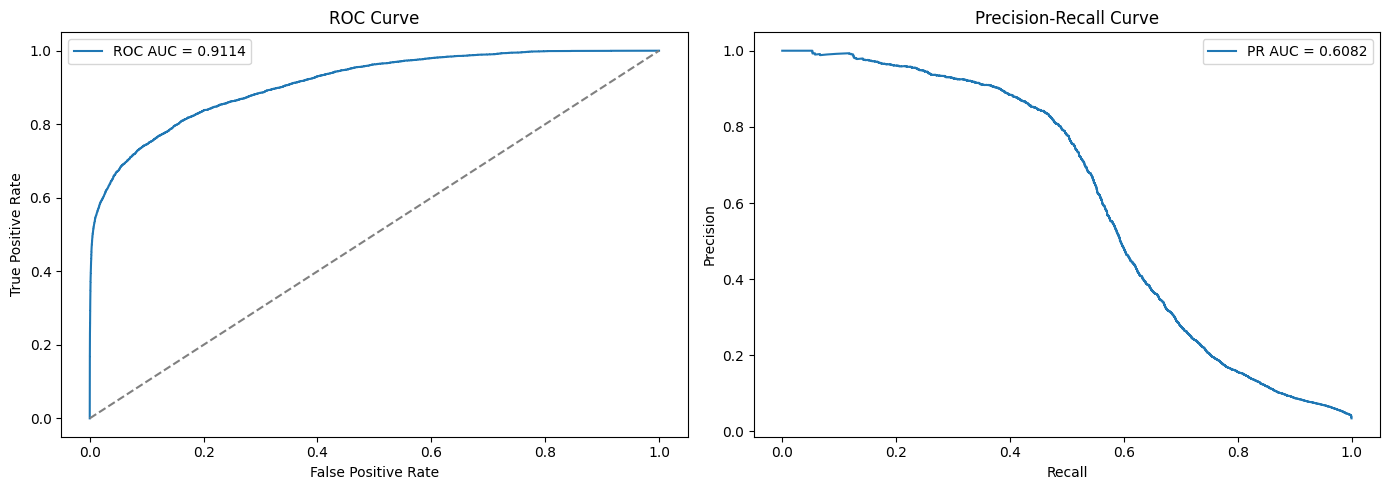

Class distribution before resampling:
isFraud
0    296404
1     12162
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    296404
1     12162
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    305225
1     10702
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    305225
1     10702
Name: count, dtype: int64
Class distribution before resampling:
isFraud
0    253055
1      8262
Name: count, dtype: int64

Class distribution after resampling:
isFraud
0    253055
1      8262
Name: count, dtype: int64
GroupKFold month-based CV AUCs: [0.9127109630061239, 0.9363260514945841, 0.9323702134768922]
GroupKFold month-based CV mean AUC: 0.9271357426592001
Validation AUC before UID2 averaging: 0.911356
Validation AUC after UID2 averaging: 0.906419
Preprocessed train shape: (590540, 225)
Categorical columns factorized: 0
Time split index: 442905
Train split shape: (442905, 225)
Valid split shape: (147635, 225)
Engineered train s

In [18]:
def run_pipeline(config: dict = CONFIG) -> dict[str, object]:
    """Run the full fraud modeling pipeline end to end and return all key artifacts."""
    section1 = section_1_data_loading_and_initial_eda(DATA_DIR)
    section2 = section_2_column_reduction(section1["train_df"], section1["test_df"], config["corr_threshold"])
    section3 = section_3_preprocessing(section2["train_df"], section2["test_df"], config)
    section4 = section_4_feature_engineering(section3["train_part"], section3["valid_part"], section3["test_df"], config)

    selection = section_6_feature_selection(
        section4["train_feat"],
        section4["valid_feat"],
        section4["feature_cols"],
        config,
    )

    tuning = section_7_hyperparameter_tuning(
        section4["train_feat"],
        selection["final_features"],
        config,
    )

    ensemble = section_8_train_ensemble(
        section4["train_feat"],
        section4["valid_feat"],
        selection["final_features"],
        tuning["best_params"],
        config,
    )

    metrics = section_9_validation_and_metrics(
        section4["train_feat"],
        section4["valid_feat"],
        ensemble["blended_pred"],
        selection["final_features"],
        tuning["best_params"],
        config,
    )

    post = section_10_uid_postprocessing(section4["valid_feat"], ensemble["blended_pred"])

    summary_metrics = {
        "val_auc_pre": post["val_auc_pre"],
        "val_auc_post": post["val_auc_post"],
        "pr_auc": metrics["pr_auc"],
    }
    output = section_11_output(
        section2["train_df"],
        section2["test_df"],
        selection["final_features"],
        tuning["best_params"],
        config,
        summary_metrics,
    )

    return {
        "section1": section1,
        "section2": section2,
        "section3": section3,
        "section4": section4,
        "selection": selection,
        "tuning": tuning,
        "ensemble": ensemble,
        "metrics": metrics,
        "postprocess": post,
        "output": output,
    }


# Uncomment the next line to execute the full pipeline end to end.
pipeline_artifacts = run_pipeline(CONFIG)

Testing thresholds from 0.01 to 0.99...

🏆 OPTIMAL BUSINESS THRESHOLD: 0.21
Best F1-Score: 0.6103
Precision: 0.7740
Recall: 0.5037

New Confusion Matrix at Optimal Threshold:
[[141785    750]
 [  2531   2569]]

✅ True Negatives (Normal Approved): 141785
❌ False Positives (False Alarms): 750
✅ True Positives (Fraud Caught): 2569
❌ False Negatives (Fraud Missed): 2531


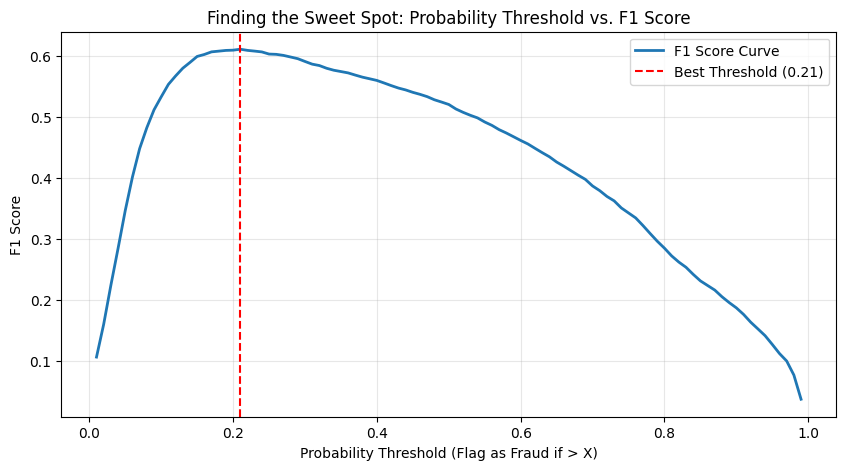

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def tune_business_threshold(y_true, y_pred_probs):
    """Loops through all possible thresholds to find the highest F1-Score."""
    print("Testing thresholds from 0.01 to 0.99...\n")
    
    thresholds = np.arange(0.01, 1.00, 0.01)
    f1_scores = []
    
    # Test every single threshold
    for thresh in thresholds:
        # Convert probabilities to 1 or 0 based on the current threshold
        binary_preds = (y_pred_probs >= thresh).astype(int)
        score = f1_score(y_true, binary_preds, zero_division=0)
        f1_scores.append(score)
        
    # Find the winner
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    # Calculate final business metrics at the winning threshold
    final_preds = (y_pred_probs >= best_thresh).astype(int)
    best_precision = precision_score(y_true, final_preds, zero_division=0)
    best_recall = recall_score(y_true, final_preds, zero_division=0)
    cm = confusion_matrix(y_true, final_preds)
    
    print(f"🏆 OPTIMAL BUSINESS THRESHOLD: {best_thresh:.2f}")
    print(f"Best F1-Score: {best_f1:.4f}")
    print(f"Precision: {best_precision:.4f}")
    print(f"Recall: {best_recall:.4f}")
    print("\nNew Confusion Matrix at Optimal Threshold:")
    print(cm)
    print(f"\n✅ True Negatives (Normal Approved): {cm[0][0]}")
    print(f"❌ False Positives (False Alarms): {cm[0][1]}")
    print(f"✅ True Positives (Fraud Caught): {cm[1][1]}")
    print(f"❌ False Negatives (Fraud Missed): {cm[1][0]}")

    # Plot the results
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, f1_scores, label='F1 Score Curve', color='#1f77b4', linewidth=2)
    plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best Threshold ({best_thresh:.2f})')
    plt.title('Finding the Sweet Spot: Probability Threshold vs. F1 Score')
    plt.xlabel('Probability Threshold (Flag as Fraud if > X)')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- RUN THE FUNCTION ---
# Since you just ran pipeline_artifacts = run_pipeline(CONFIG), 
# we need to grab the true labels and your model's predictions from it.
# (Note: adjust the dictionary keys below if your pipeline named them differently!)

try:
    # Extract the validation true labels (isFraud) and the predicted probabilities
    valid_labels = pipeline_artifacts["section4"]["valid_feat"]["isFraud"]
    valid_probabilities = pipeline_artifacts["ensemble"]["blended_pred"]
    
    # Run the tuner!
    tune_business_threshold(valid_labels, valid_probabilities)
except KeyError as e:
    print(f"Oops! Couldn't find the exact dictionary key: {e}")
    print("Check how your pipeline_artifacts dictionary is structured to pass the correct labels and predictions to the function.")

In [22]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.optimize import minimize

# 1. Grab the validation data and true labels
final_features = pipeline_artifacts["selection"]["final_features"]
valid_X = pipeline_artifacts["section4"]["valid_feat"][final_features]
valid_y = pipeline_artifacts["section4"]["valid_feat"]["isFraud"]

# 2. Grab the three trained models from the pipeline
xgb_model = pipeline_artifacts["ensemble"]["xgb_model"]
lgbm_model = pipeline_artifacts["ensemble"]["lgbm_model"]
cat_model = pipeline_artifacts["ensemble"]["cat_model"]

print("Generating individual model predictions...")
# 3. Get the individual predictions from each model
pred_xgb = xgb_model.predict_proba(valid_X)[:, 1]
pred_lgbm = lgbm_model.predict_proba(valid_X)[:, 1]
pred_cat = cat_model.predict_proba(valid_X)[:, 1]

# 4. Define the function we want to optimize (Maximize AUC)
def roc_auc_objective(weights):
    # Ensure weights sum to 1
    weights = weights / np.sum(weights)
    
    # Create the blended prediction
    blended_pred = (weights[0] * pred_xgb) + (weights[1] * pred_lgbm) + (weights[2] * pred_cat)
    
    # Scipy minimize tries to find the LOWEST number, so we make AUC negative
    return -roc_auc_score(valid_y, blended_pred)

# 5. Set up the optimizer
# We start with an equal 33% guess for all three
initial_weights = [1/3, 1/3, 1/3]

# Weights must be between 0.0 and 1.0
bounds = [(0, 1), (0, 1), (0, 1)]

# Run the optimizer!
print("Finding optimal ensemble weights...\n")
result = minimize(roc_auc_objective, initial_weights, bounds=bounds, method='Nelder-Mead')

# 6. Extract and normalize the winning weights
best_weights = result.x / np.sum(result.x)

# 7. Compare Old vs. New
old_blend = (pred_xgb + pred_lgbm + pred_cat) / 3
new_blend = (best_weights[0] * pred_xgb) + (best_weights[1] * pred_lgbm) + (best_weights[2] * pred_cat)

print("🏆 OPTIMIZATION COMPLETE 🏆")
print("-" * 30)
print(f"XGBoost Weight:  {best_weights[0]*100:.2f}%")
print(f"LightGBM Weight: {best_weights[1]*100:.2f}%")
print(f"CatBoost Weight: {best_weights[2]*100:.2f}%")
print("-" * 30)
print(f"Baseline (Simple Average) AUC: {roc_auc_score(valid_y, old_blend):.6f}")
print(f"Optimized (Weighted) AUC:      {-result.fun:.6f}")
print(f"Baseline PR-AUC:               {average_precision_score(valid_y, old_blend):.6f}")
print(f"Optimized PR-AUC:              {average_precision_score(valid_y, new_blend):.6f}")

Generating individual model predictions...
Finding optimal ensemble weights...

🏆 OPTIMIZATION COMPLETE 🏆
------------------------------
XGBoost Weight:  69.05%
LightGBM Weight: 20.58%
CatBoost Weight: 10.38%
------------------------------
Baseline (Simple Average) AUC: 0.881816
Optimized (Weighted) AUC:      0.889193
Baseline PR-AUC:               0.520506
Optimized PR-AUC:              0.521384


## Notes

- Resampling is always applied after the time split and only to the training fold.
- Target encoding is out-of-fold on training data only.
- UID and deviation lookup tables are fit on training history only, then mapped to validation and test.
- Sequential velocity features are computed chronologically and only use prior transactions.
- The final execution line is intentionally commented to keep notebook creation lightweight; remove the `#` to run the full pipeline.